In [2]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
import statsmodels.api as sm
from matplotlib.patches import Patch

In [4]:
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
df = pd.read_csv('IPFQR_QualityMeasures_Facility.csv')

In [7]:
df['READM-30-IPF Rate'] = pd.to_numeric(df['READM-30-IPF Rate'], errors = 'coerce')

In [8]:
data = df['READM-30-IPF Rate'].dropna()

In [9]:
counts, big_edges = np.histogram(data, bins = 20)

In [10]:
bin_centers = 0.5 * (big_edges[:-1] + big_edges[1:])

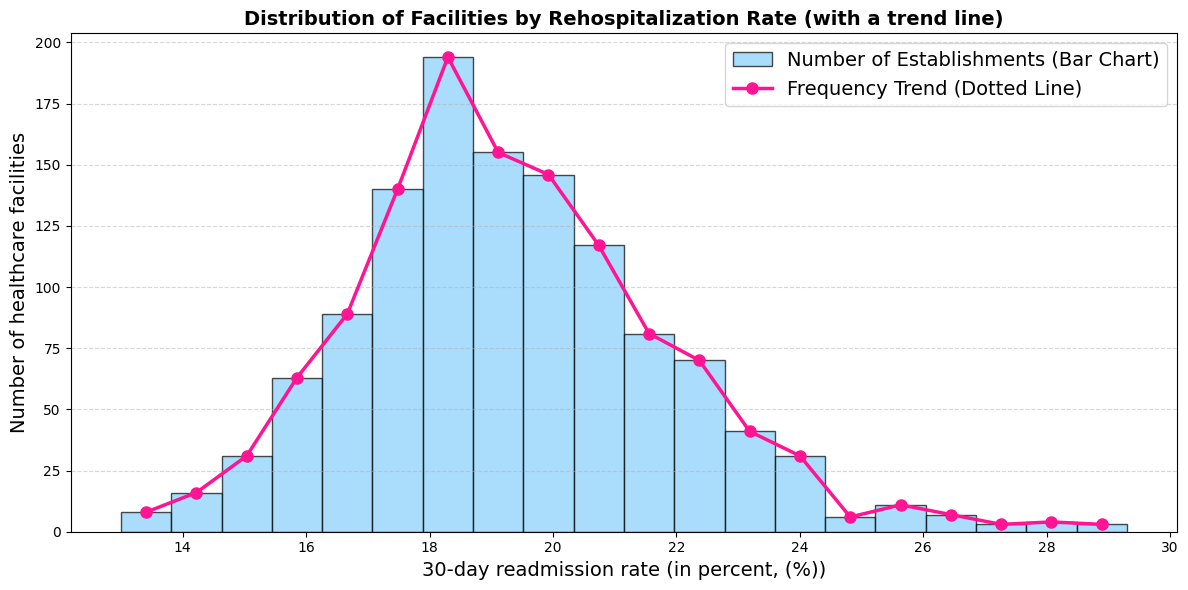

In [11]:
plt.figure(figsize = (12, 6))
plt.hist(
    data,
    bins = 20,
    color = '#87CEFA',
    edgecolor = 'black',
    alpha = 0.7,
    label = 'Number of Establishments (Bar Chart)'
)
plt.plot(
    bin_centers,
    counts,
    marker = 'o',
    color = '#FF1493',
    linestyle = '-',
    linewidth = 2.5,
    markersize = 8,
    label = 'Frequency Trend (Dotted Line)'
)
plt.title(
    'Distribution of Facilities by Rehospitalization Rate (with a trend line)',
    fontsize = 14,
    fontweight = 'bold'
)
plt.xlabel(
    '30-day readmission rate (in percent, (%))',
    fontsize = 14
)
plt.ylabel(
    'Number of healthcare facilities',
    fontsize = 14
)
plt.legend(
    fontsize = 14,
    loc = "upper right"
)
plt.grid(
    axis = 'y',
    linestyle = '--',
    alpha = 0.5
)
plt.tight_layout()
plt.savefig('HistogramLineCombination_IPFQR_QualityMeasures_Facility')
plt.show()

In [7]:
set_of_states = df['State'].value_counts().head(12).index
subset_df = df[df['State'].isin(set_of_states)]
crosstab = pd.crosstab(subset_df['State'], subset_df['READM-30-IPF Category'])
crosstab['Total Number Of Facilities'] = crosstab.sum(axis = 1)
crosstab.sort_values(
    'Total Number Of Facilities',
    ascending = True
).drop('Total Number Of Facilities', axis = 1)
colors = ['#88cfae', '#f4a6c1', '#8cb8e5', '#fcd595', '#c3aed6', '#de7a76']
plt.style.use('seaborn-v0_8-whitegrid')

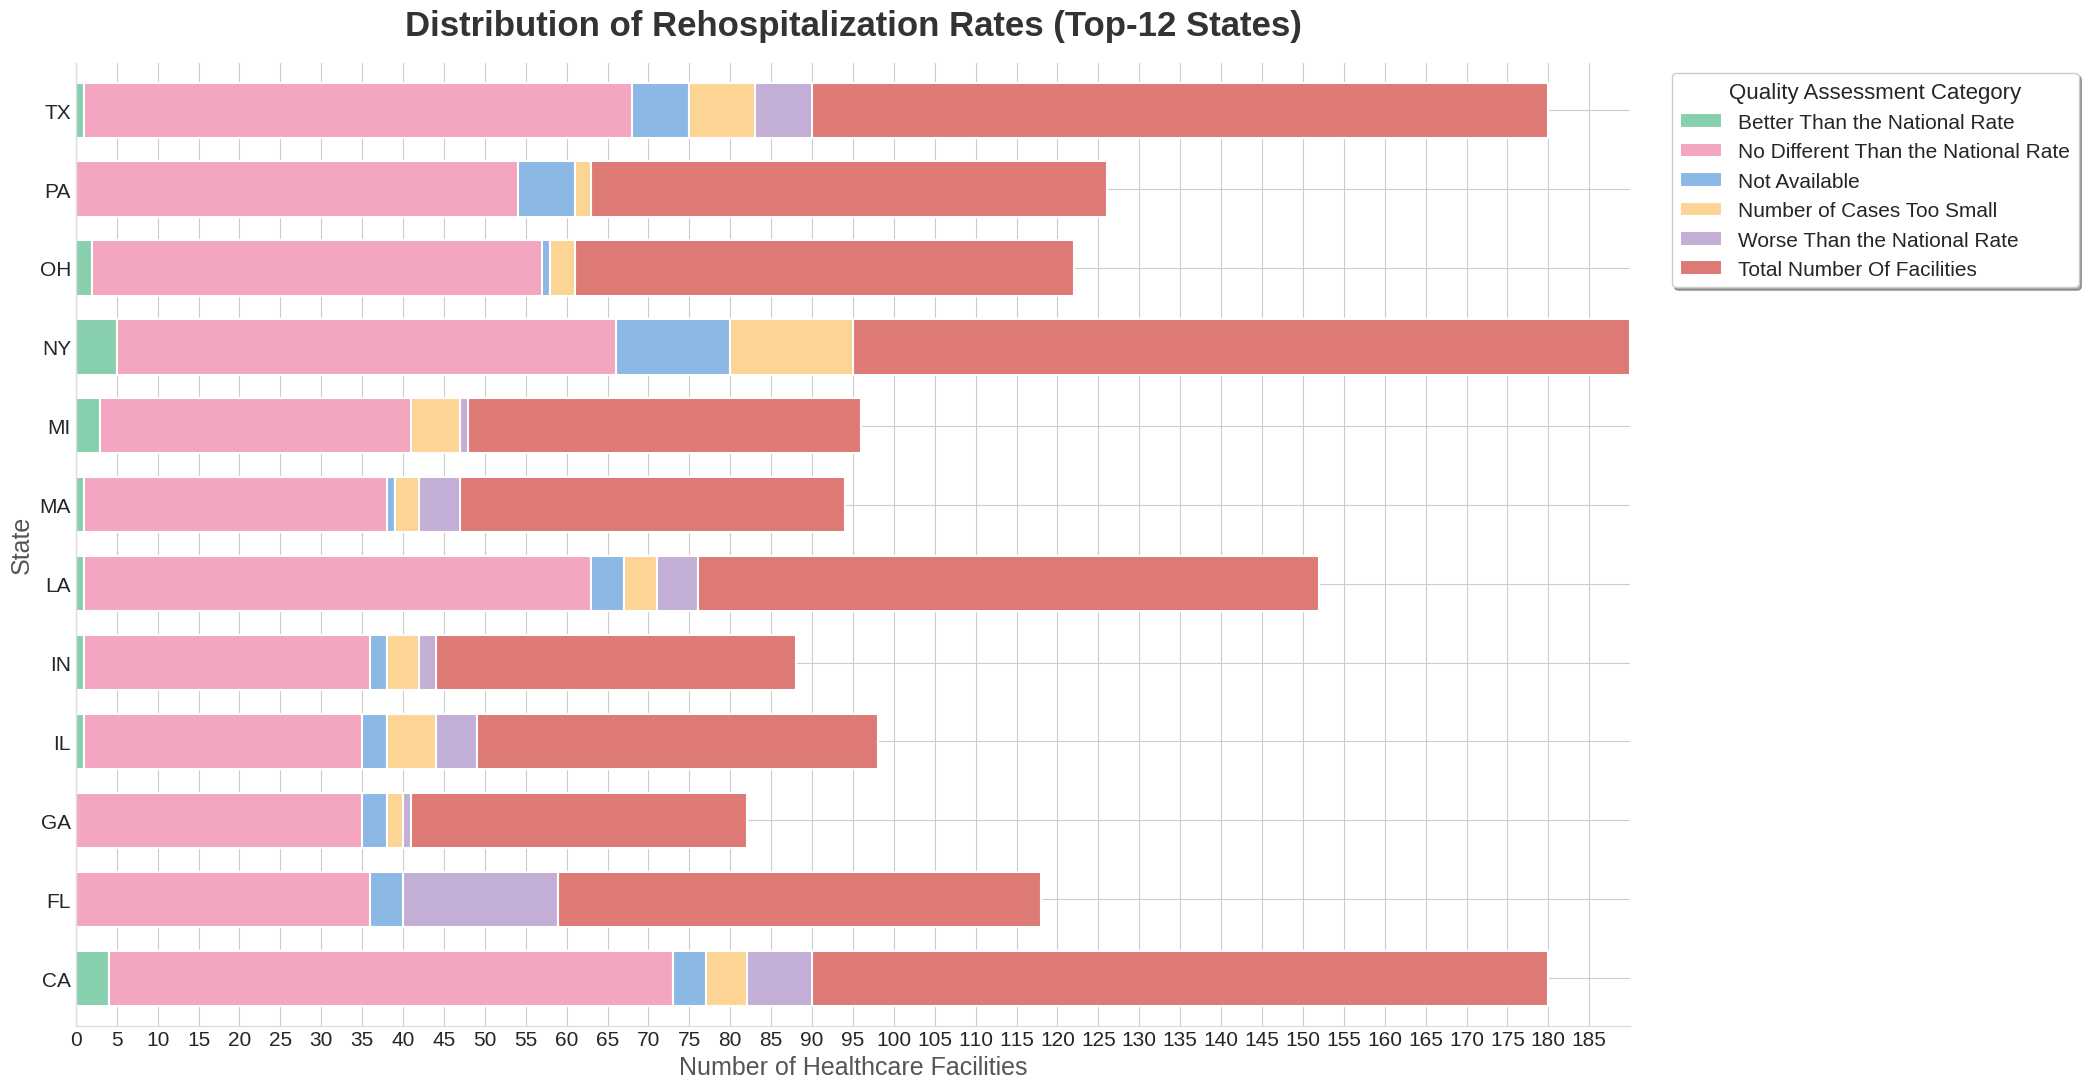

In [19]:
fig, ax = plt.subplots(figsize = (21, 11))
crosstab.plot(
    kind = 'barh',
    stacked = True,
    color = colors[:len(crosstab.columns)],
    ax = ax,
    width = 0.7,
    edgecolor = 'white',
    linewidth = 1.5
)
ax.set_title(
    'Distribution of Rehospitalization Rates (Top-12 States)',
    fontsize = 25,
    fontweight = 'bold',
    pad = 20,
    color = '#333333',
)
ax.set_xlabel(
    'Number of Healthcare Facilities',
    fontsize = 18,
    color = '#555555'
)
ax.set_ylabel(
    'State',
    fontsize = 18,
    color = '#555555'
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#dddddd')
ax.spines['bottom'].set_color('#dddddd')
ax.legend(
    title = 'Quality Assessment Category',
    title_fontsize = 16,
    bbox_to_anchor = (1.02, 1),
    loc = 'upper left',
    fontsize = 15,
    frameon = True,
    fancybox = True,
    shadow = True
)
plt.xlim(0, 190)
plt.xticks(
    np.arange(0, 190, 5),
    fontsize = 15
)
plt.yticks(fontsize = 15)
plt.tight_layout()
plt.savefig(
    'AestheticStackedBar_IPFQR_QualityMeasures_Facility.png',
    dpi = 300,
    bbox_inches = 'tight'
)
plt.show()

In [ ]:
# We read our set of medical data from a CSV-file into a DataFrame (table)
df = pd.read_csv("IPFQR_QualityMeasures_Facility.csv")

In [ ]:
# Since the column containing the rate of readmissions (READM-30-IPF Rate) might contain text values,
#  we force it to be converted to numbers. The parameter `errors=‘coerce’` means that any invalid
#  values (such as text or spaces) will be converted to NaN
df['READM-30-IPF Rate'] = pd.to_numeric(df['READM-30-IPF Rate'], errors = 'coerce')

In [ ]:
# We clean the data by completely removing all rows that are missing information about the
# hospitalization rate and the state name. The .copy() method ensures that we are working with an
# independent subset of the data.
filtered_valid_rates_df = df.dropna(
    subset = ['READM-30-IPF Rate', 'State']
).copy()

In [ ]:
# For easier grouping, we round the hospitalization rates to whole numbers using the `round()` and
# `astype(int)` functions and store them in a new column called `Rounded_Rate`.
filtered_valid_rates_df['Rounded_Rate'] = filtered_valid_rates_df['READM-30-IPF Rate'].round().astype(int)

In [ ]:
# We analyze the list of states and select the 5 states with the highest number of medical facilities
# and institutions
set_of_states = df['State'].value_counts().head(5).index

In [ ]:
# We filter our table so that it contains data only for these top-5 states
set_of_states_df = filtered_valid_rates_df[filtered_valid_rates_df['State'].isin(set_of_states)]

In [ ]:
# We filter our data based on the Hospitalization Rate and Staffing metrics and count the number of
# healthcare facilities.Next, we convert our rows containing states into a column. If there are no
# establishments for a given percentage in a particular state, we fill that cell with a zero.
grouped_by_df = set_of_states_df.groupby(['Rounded_Rate', 'State']).size().unstack(fill_value = 0)

In [ ]:
# We “trim” the excess and focus on the percentage range needed to plot the graph
grouped_by_df = grouped_by_df.loc[16:23]

In [ ]:
# Let's set a harmonious color palette for each state
colors = ['#f8b8d0', '#fce4ec', '#5c3a93', '#a991c8', '#f392b8']

In [ ]:
# We're using a built-in style that adds a pure white background with a light grid
plt.style.use('seaborn-v0_8-whitegrid')

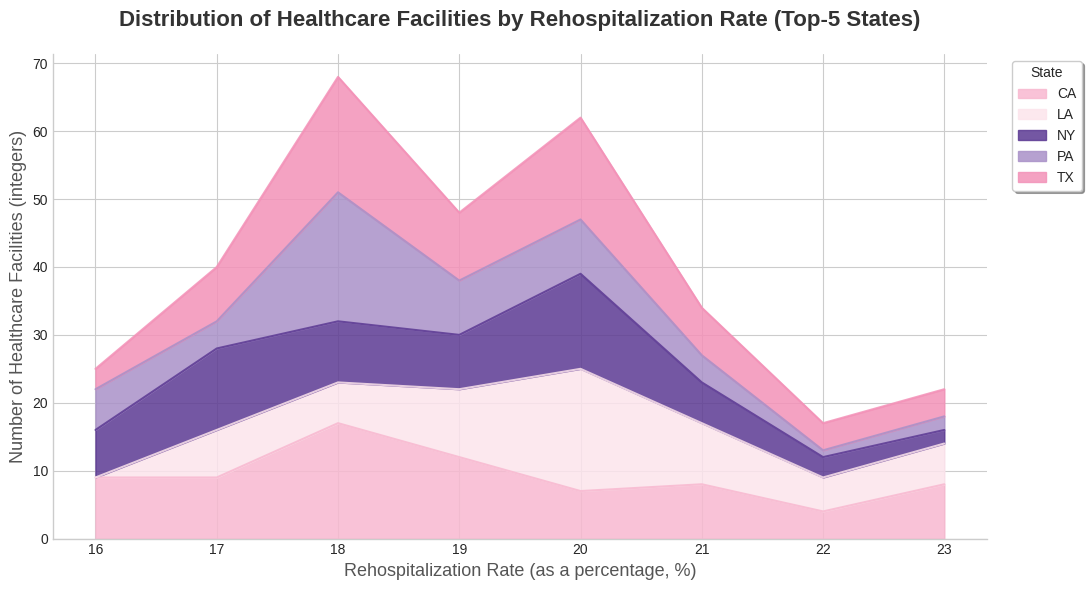

In [ ]:
# We are creating a “canvas” for drawing that is 11 inches wide and 6 inches tall
fig, ax = plt.subplots(figsize = (11, 6))
# Let's call the command to draw a diagram with regions
grouped_by_df.plot(
    # Next, we'll explain that we're now going to create a chart with regions
    kind = 'area',
    # It overlays the regions on top of each other so that we can see the total number of medical facilities
    stacked = True,
    # Next, we specify that we want to use a harmonious color palette from our list
    color = colors[:len(set_of_states)],
    ax = ax,
    # Makes the colors slightly transparent by 15%, which adds a sense of visual lightness
    alpha = 0.85
)
# Next, we add attractive, clear labels to the chart and both axes, adjusting their size, font weight, and color
ax.set_title(
    'Distribution of Healthcare Facilities by Rehospitalization Rate (Top-5 States)',
    fontsize = 16,
    fontweight = 'bold',
    pad = 20,
    color = '#333333'
)
ax.set_xlabel(
    'Rehospitalization Rate (as a percentage, %)',
    fontsize = 13,
    color = '#555555'
)
ax.set_ylabel(
    'Number of Healthcare Facilities (integers)',
    fontsize = 13,
    color = '#555555'
)
# Next, we move the legend outside the chart itself so it doesn't overlap the data, and add a border and a shadow
ax.legend(
    title = 'State',
    bbox_to_anchor = (1.02, 1),
    loc = 'upper left',
    frameon = True,
    shadow = True
)
# Next, we remove the top and right borders of the graph to visually “open up” the graph and reduce information noise
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# We automatically adjust the titles, axes, and legend so that they aren't cut off and look aesthetically pleasing
plt.tight_layout()
# We save our chart in high-quality PNG format, and the ‘bbox_inches’ parameter ensures that all off-screen elements
# won't be cropped or lost, but will be included in our image
plt.savefig(
    'StackedAreaChart_IPFQR_QualityMeasures_Facility.png',
    dpi = 300,
    bbox_inches = 'tight'
)
# Finally, we're bringing this beauty to the screen!
plt.show()

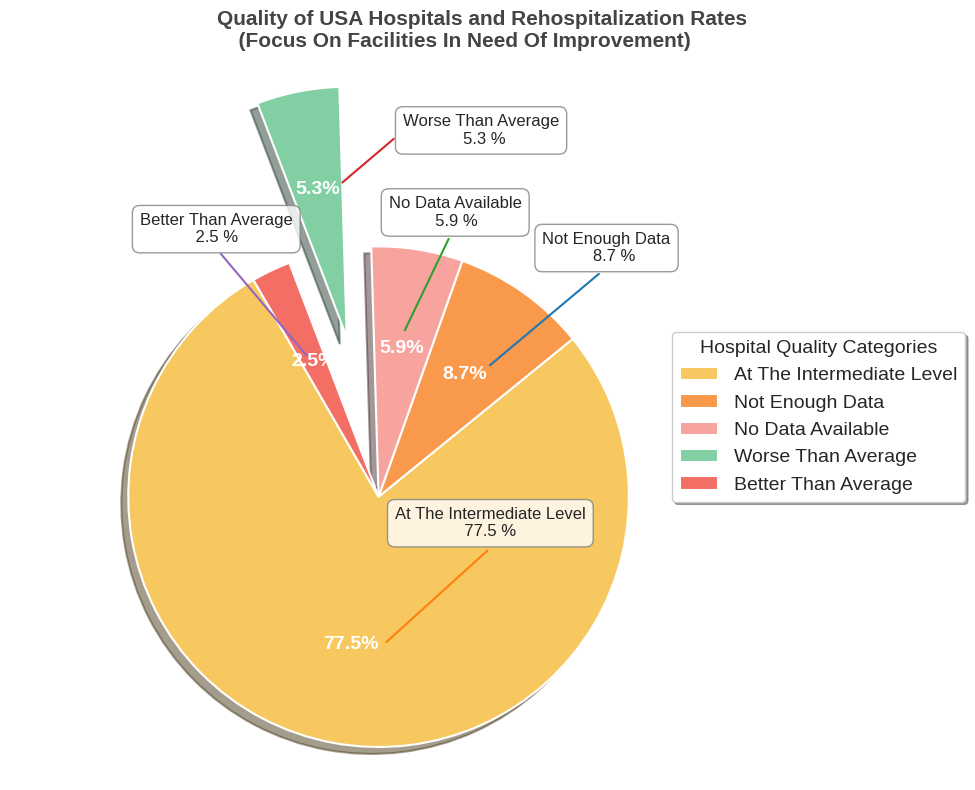

In [ ]:
df = pd.read_csv("IPFQR_QualityMeasures_Facility.csv")
category_counts = df['READM-30-IPF Category'].value_counts()
labels_map = {
  'No Different Than the National Rate': 'At The Intermediate Level',
  'Number of Cases Too Small': 'Not Enough Data',
  'Not Available': 'No Data Available',
  'Worse Than the National Rate': 'Worse Than Average',
  'Better Than the National Rate': 'Better Than Average'
}
labels = [labels_map.get(label, label) for label in category_counts.index]
sizes = category_counts.values
explode = [0.65 if label == 'Worse Than Average' else 0 for label in labels]
colors = ['#f6c85f', '#f9994c', '#f7a49f', '#81cfa2', '#f36e65']
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize = (9, 8))
wedges, texts, autotexts = ax.pie(
  sizes,
  explode = explode,
  labels = None,
  autopct = '%1.1f%%',
  shadow = True,
  startangle = 120,
  colors = colors,
  wedgeprops = {
    'edgecolor': 'white',
    'linewidth': 1.5
  },
  textprops = {
    'fontsize': 14,
    'fontweight': 'bold',
    'color': 'white'
  }
)
ax.legend(
    wedges,
    labels,
    title = "Hospital Quality Categories",
    loc = "center left",
    bbox_to_anchor = (1, 0, 0.5, 1),
    fontsize = 14,
    title_fontsize = 14,
    frameon = True,
    shadow = True
)
ax.axis('equal')
plt.title(
    '                                    Quality of USA Hospitals and Rehospitalization Rates\n                              (Focus On Facilities In Need Of Improvement)',
    fontsize = 15,
    fontweight = 'bold',
    pad = 5,
    color = '#444444'
)
x1 = [0.445, 0.880]
y1 = [0.525, 0.890]
x2 = [0.435, 0.031]
y2 = [-0.215, -0.581]
x3 = [0.105, 0.280]
y3 = [0.665, 1.030]
x4 = [-0.145, 0.061]
y4 = [1.255, 1.430]
x5 = [-0.288, -0.630]
y5 = [0.565, 0.970]
plt.plot(x1, y1)
plt.plot(x2, y2)
plt.plot(x3, y3)
plt.plot(x4, y4)
plt.plot(x5, y5)
plt.text(
  0.789,
  0.755,
  "Not Enough Data\n           8.7 %",
  transform = plt.gca().transAxes,
  fontsize = 12,
  verticalalignment = 'top',
  bbox = dict(
      boxstyle = 'round, pad = 0.45',
      facecolor = 'white',
      alpha = 0.8,
      edgecolor = 'gray'
  )
)
plt.text(
  0.529,
  0.376,
  "At The Intermediate Level\n               77.5 %",
  transform = plt.gca().transAxes,
  fontsize = 12,
  verticalalignment = 'top',
  bbox = dict(
      boxstyle = 'round, pad = 0.45',
      facecolor = 'white',
      alpha = 0.8,
      edgecolor = 'gray'
  )
)
plt.text(
  0.518,
  0.804,
  "No Data Available\n          5.9 %",
  transform = plt.gca().transAxes,
  fontsize = 12,
  verticalalignment = 'top',
  bbox = dict(
      boxstyle = 'round, pad = 0.45',
      facecolor = 'white',
      alpha = 0.8,
      edgecolor = 'gray'
  )
)
plt.text(
  0.543,
  0.917,
  "Worse Than Average\n             5.3 %",
  transform = plt.gca().transAxes,
  fontsize = 12,
  verticalalignment = 'top',
  bbox = dict(
      boxstyle = 'round, pad = 0.45',
      facecolor = 'white',
      alpha = 0.8,
      edgecolor = 'gray'
  )
)
plt.text(
  0.079,
  0.781,
  "Better Than Average\n            2.5 %",
  transform = plt.gca().transAxes,
  fontsize = 12,
  verticalalignment = 'top',
  bbox = dict(
      boxstyle = 'round, pad = 0.45',
      facecolor = 'white',
      alpha = 0.8,
      edgecolor = 'gray'
  )
)
plt.tight_layout()
plt.savefig(
    'pie_with_legend.png',
    dpi = 300,
    bbox_inches = 'tight'
)
plt.show()

In [ ]:
print(os.listdir('.'))

['.config', 'sample_data']


In [ ]:
df = pd.read_csv('IPFQR_QualityMeasures_Facility.csv')

In [ ]:
df.head()

,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,HBIPS-2 Measure Description,HBIPS-2 Overall Rate Per 1000,HBIPS-2 Overall Num,...,READM-30-IPF Higher Estimate,READM-30-IPF Footnote,READM-30-IPF Start Date,READM-30-IPF End Date,IMM-2 Measure Description,IMM-2 %,IMM-2 Denominator,IMM-2 Footnote,Flu Season Start Date,Flu Season End Date
0,10007,MIZELL MEMORIAL HOSPITAL,702 N MAIN ST,OPP,AL,36467,COVINGTON,Hours of physical-restraint use,0.00,0,...,27.2,NaN,07/01/2022,06/30/2024,Influenza immunization (IPFQR-IMM-2),68,40,NaN,10/01/2024,03/31/2025
1,10011,ST. VINCENT'S EAST,50 MEDICAL PARK EAST DRIVE,BIRMINGHAM,AL,35235,JEFFERSON,Hours of physical-restraint use,Not Available,Not Available,...,25.7,29.0,07/01/2022,06/30/2024,Influenza immunization (IPFQR-IMM-2),78,190,NaN,10/01/2024,03/31/2025
2,10012,DEKALB REGIONAL MEDICAL CENTER,200 MED CENTER DRIVE,FORT PAYNE,AL,35968,DE KALB,Hours of physical-restraint use,0.00,0,...,23.8,NaN,07/01/2022,06/30/2024,Influenza immunization (IPFQR-IMM-2),95,66,NaN,10/01/2024,03/31/2025
3,10016,SHELBY BAPTIST MEDICAL CENTER,1000 FIRST STREET NORTH,ALABASTER,AL,35007,SHELBY,Hours of physical-restraint use,0.00,0,...,28.3,NaN,07/01/2022,06/30/2024,Influenza immunization (IPFQR-IMM-2),97,313,NaN,10/01/2024,03/31/2025
4,10021,DALE MEDICAL CENTER,126 HOSPITAL AVE,OZARK,AL,36360,DALE,Hours of physical-restraint use,0.00,0,...,23.5,NaN,07/01/2022,06/30/2024,Influenza immunization (IPFQR-IMM-2),59,44,NaN,10/01/2024,03/31/2025


In [ ]:
print(df.columns.tolist())

['Facility ID', 'Facility Name', 'Address', 'City/Town', 'State', 'ZIP Code', 'County/Parish', 'HBIPS-2 Measure Description', 'HBIPS-2 Overall Rate Per 1000', 'HBIPS-2 Overall Num', 'HBIPS-2 Overall Den', 'HBIPS-2 Overall Footnote', 'HBIPS-3 Measure Description', 'HBIPS-3 Overall Rate Per 1000', 'HBIPS-3 Overall Num', 'HBIPS-3 Overall Den', 'HBIPS-3 Overall Footnote', 'SMD Measure Description', 'SMD %', 'SMD Denominator', 'SMD Footnote', 'SUB-2/-2a Measure Description', 'SUB-2 %', 'SUB-2 Denominator', 'SUB-2 Footnote', 'SUB-2a %', 'SUB-2a Denominator', 'SUB-2a Footnote', 'SUB-3/-3a Measure Description', 'SUB-3 %', 'SUB-3 Denominator', 'SUB-3 Footnote', 'SUB-3a %', 'SUB-3a Denominator', 'SUB-3a Footnote', 'TOB-3/-3a Measure Description', 'TOB-3 %', 'TOB-3 Denominator', 'TOB-3 Footnote', 'TOB-3a %', 'TOB-3a Denominator', 'TOB-3a Footnote', 'TR-1 Measure Description', 'TR-1 %', 'TR-1 Denominator', 'TR-1 Footnote', 'Start Date', 'End Date', 'FAPH Measure Description', 'FAPH-30 %', 'FAPH-30

In [ ]:
target = 'READM-30-IPF Rate'
features = [
    'HBIPS-2 Overall Rate Per 1000', 'HBIPS-3 Overall Rate Per 1000',
    'SMD %', 'SUB-2 %', 'SUB-2a %', 'SUB-3 %', 'SUB-3a %',
    'TOB-3 %', 'TOB-3a %', 'TR-1 %', 'FAPH-30 %', 'FAPH-7 %',
    'MedCont %', 'IMM-2 %'
]

In [ ]:
df[target] = pd.to_numeric(df[target], errors = 'coerce')
for column in features:
  df[column] = pd.to_numeric(df[column], errors = 'coerce')

In [ ]:
regression_analysis_df = df.dropna(subset = [target] + features).copy()

In [ ]:
X = regression_analysis_df[features]
y = regression_analysis_df[target]

In [ ]:
X_statsmodels = sm.add_constant(X)
fit_model = sm.OLS(y, X_statsmodels).fit()
print(fit_model.summary())

                            OLS Regression Results                            
Dep. Variable:      READM-30-IPF Rate   R-squared:                       0.168
Model:                            OLS   Adj. R-squared:                  0.146
Method:                 Least Squares   F-statistic:                     7.605
Date:                Sun, 09 Aug 2026   Prob (F-statistic):           1.12e-14
Time:                        20:34:23   Log-Likelihood:                -1263.8
No. Observations:                 542   AIC:                             2558.
Df Residuals:                     527   BIC:                             2622.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

In [ ]:
coefficients = fit_model.params.drop('const')
errors = fit_model.bse.drop('const')
pvalues = fit_model.pvalues.drop('const')

In [ ]:
coefficients_df = pd.DataFrame({
    'Coefficient': coefficients,
    'Std_Error': errors,
    'P-value': pvalues
}).sort_values(by = 'Coefficient')

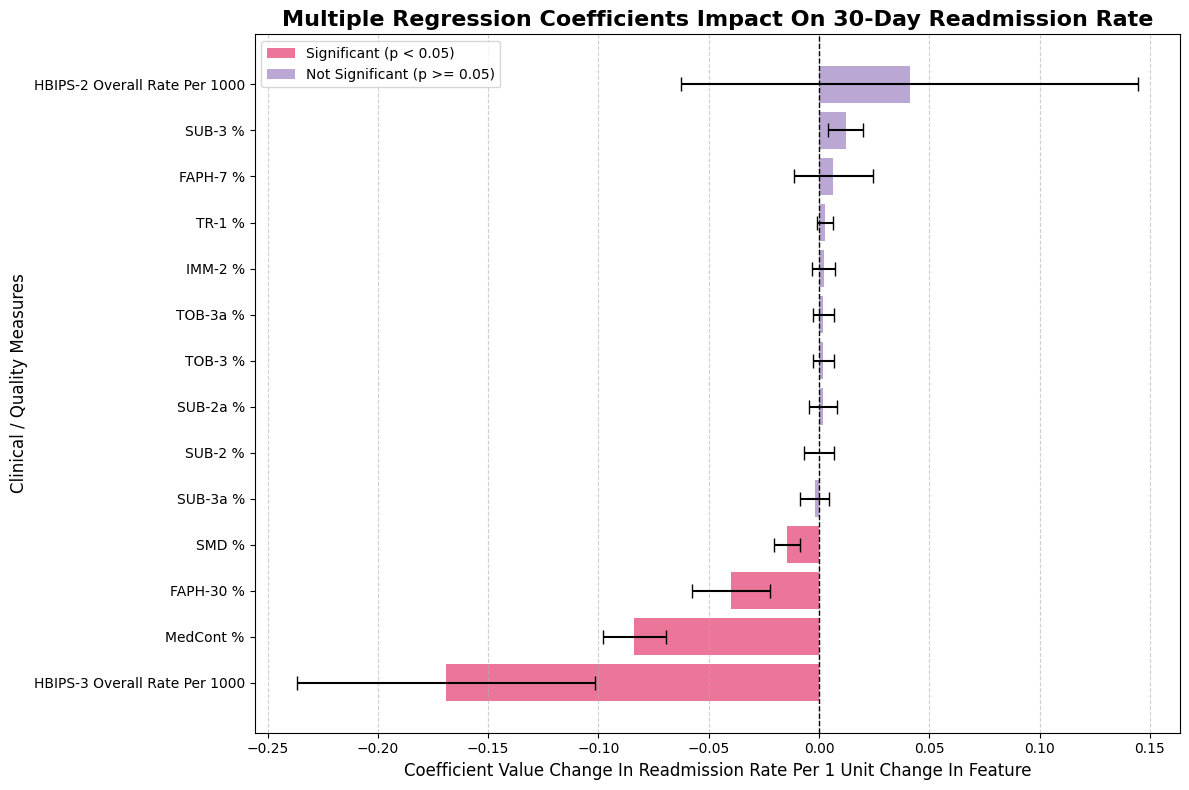

In [ ]:
plt.figure(figsize = (12, 8))
colors = ['#e75480' if p < 0.05 else '#a991c8' for p in coefficients_df['P-value']]
plt.barh(
    coefficients_df.index,
    coefficients_df['Coefficient'],
    xerr = coefficients_df['Std_Error'],
    color = colors,
    alpha = 0.8,
    capsize = 5
)
plt.axvline(
    0,
    color = 'black',
    linestyle = '--',
    linewidth = 1
)
plt.title(
    'Multiple Regression Coefficients Impact On 30-Day Readmission Rate',
    fontsize = 16,
    fontweight = 'bold'
)
plt.xlabel(
    'Coefficient Value Change In Readmission Rate Per 1 Unit Change In Feature',
    fontsize = 12
)
plt.ylabel(
    'Clinical / Quality Measures',
    fontsize = 12
)
plt.grid(
    axis = 'x',
    linestyle = '--',
    alpha = 0.6
)
legend_elements = [
    Patch(
        facecolor = '#e75480',
        alpha = 0.8,
        label = 'Significant (p < 0.05)'
    ),
    Patch(
        facecolor='#a991c8',
        alpha = 0.8,
        label = 'Not Significant (p >= 0.05)'
    )
]
plt.legend(
    handles = legend_elements,
    loc = 'best'
)
plt.tight_layout()
plt.savefig(
    'MultipleRegressionCoefficients_IPFQR_QualityMeasures_Facility.png',
    dpi = 300
)
plt.show()

In [ ]:
predictions = fit_model.predict(X_statsmodels)

/tmp/ipykernel_2547/442842098.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


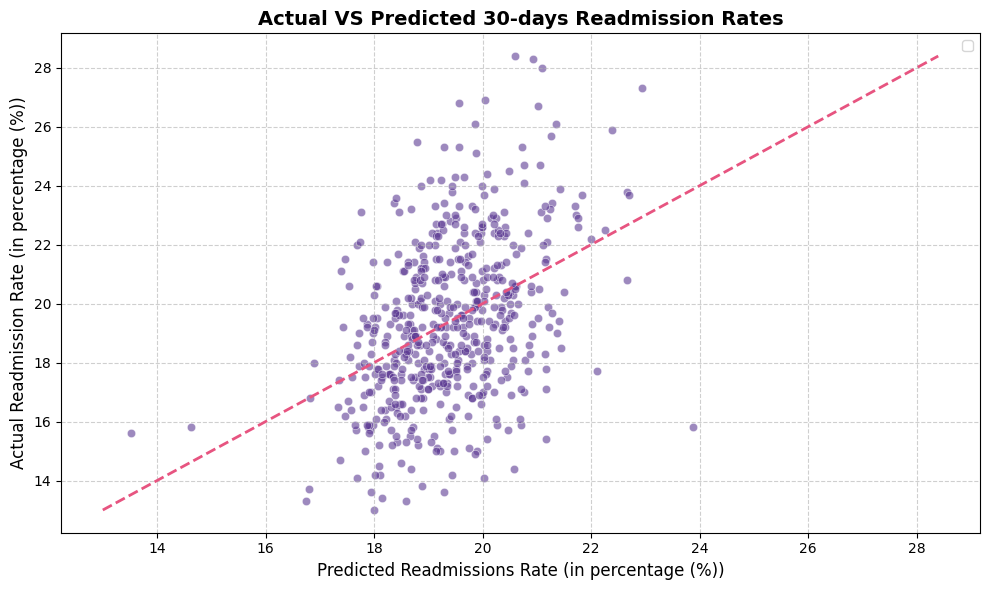

In [ ]:
plt.figure(figsize = (10, 6))
sns.scatterplot(
    x = predictions,
    y = y,
    color = '#5c3a93',
    alpha = 0.6
)
plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    color = '#e75480',
    linestyle = '--',
    linewidth = 2
)
plt.title(
    'Actual VS Predicted 30-days Readmission Rates',
    fontsize = 14,
    fontweight = 'bold'
)
plt.xlabel(
    'Predicted Readmissions Rate (in percentage (%))',
    fontsize = 12
)
plt.ylabel(
    'Actual Readmission Rate (in percentage (%))',
    fontsize = 12
)
plt.grid(
    True,
    linestyle = '--',
    alpha = 0.6
)
plt.tight_layout()
plt.savefig(
    'Actual_vs_Predicted_Multiple_Regression_IPFQR_QualityMeasures_Facility.png',
    dpi = 300
)
plt.show()

In [ ]:
df.to_csv('processed_healthcare_data.csv', index = False)

NameError: name 'df' is not defined